# cosine correction comparison

## read cosine corrected

In [3]:
import atmPy.radiation.retrievals.spectral_irradiance as atmsi

In [4]:
import atmPy.general.measurement_site as atmsite

In [5]:
plt.rcParams['figure.dpi'] = 200

/var/folders/f4/dl3whmyd1rj_9smbyhmyqyj1h26f40/T/ipykernel_6243/1907359595.py:14: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(fl)


None
2026-03-04 00:00:00


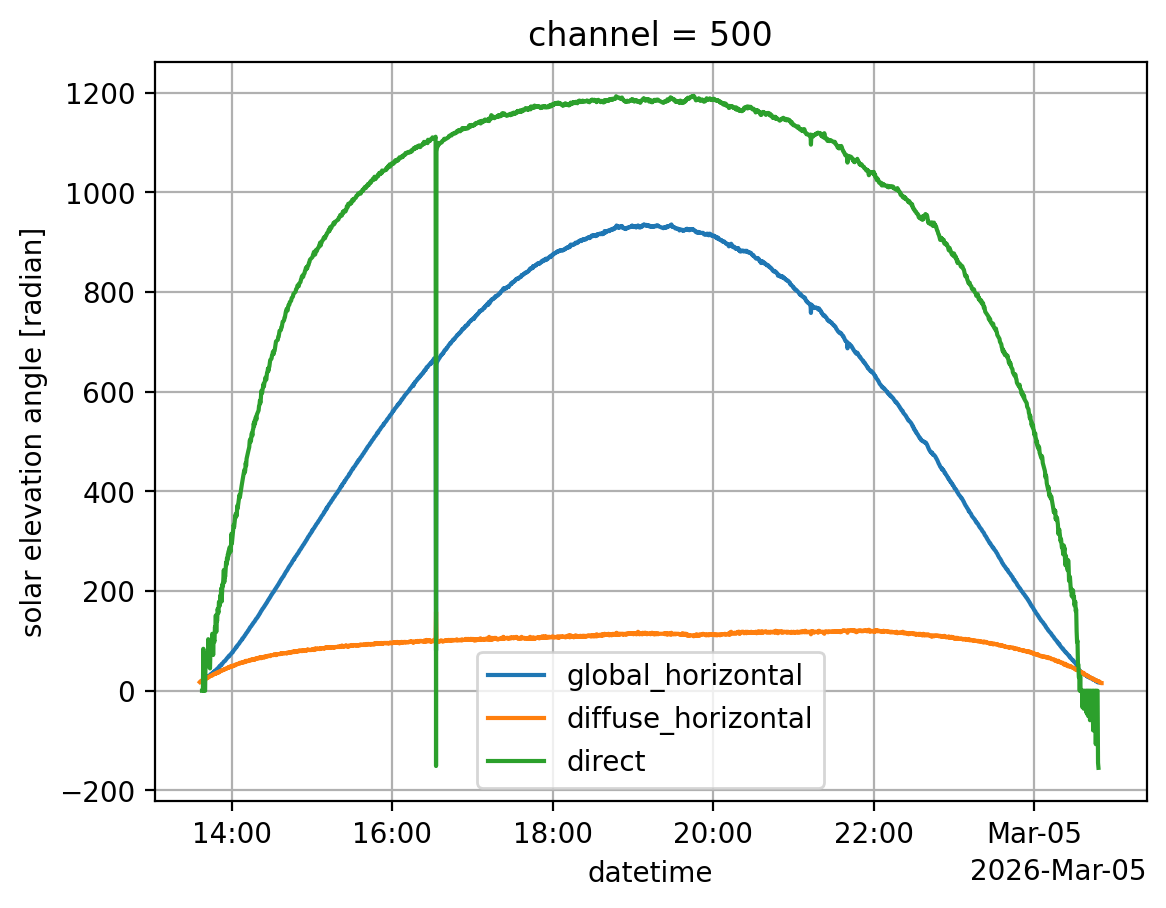

In [7]:
i = None 
site = 'tbl'
if 0:
    # i = -1
    # i = 12 # 2026-03-04 strange spike
    # i = 15
    # i += 1
    p2fld = pl.Path(f'/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/cosine_corrected/v0.2/2026/')
    fl = list(p2fld.glob('*.nc'))
    fl.sort()
    ds = xr.open_mfdataset(fl[slice(i,i+2)])
else:
    fl = [f'/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/cosine_corrected/v0.2/2026/{site}_mfrsr_cosinecorrected_20260304.nc',
          f'/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/cosine_corrected/v0.2/2026/{site}_mfrsr_cosinecorrected_20260305.nc',]
    ds = xr.open_mfdataset(fl)

site = atmsite.Station(lat = ds.site_latitude, lon = ds.site_longitude, name = ds.site_name)
tdiff = pd.to_timedelta(site.time_zone['diff2UTC_of_standard_time'], 'h')
dt_local = pd.DatetimeIndex(ds.datetime + tdiff)
start = dt_local[0].ceil("D")
end = start  + pd.to_timedelta(1, 'D') - pd.to_timedelta(1, 'ns')
assert(start.date() == end.date()), f'Start ({start}) and end ({end}) timestamps are on different days, this should not happen!?!'
ds = ds.sel(datetime = slice(start - tdiff, end - tdiff))
print(i)
print(start)

# ds = xr.open_dataset(p2f)
dscc = atmsi.CombinedGlobalDiffuseDirect(ds)
dscc.plot_overview()
None

In [8]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.surfrad.surfrad as atmsrf

In [12]:
# si_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/tu/2026/tbl_mfrsr_20260106_D824_3126_660.tu'), raisefilterfunctionerror=False)
si_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/tu/2026/tbl_mfrsr_20260304_D824_3126_660.tu'), raisefilterfunctionerror=False)
tu_raw = si_tu.dataset.copy()

si_tu.dataset = si_tu.dataset.reindex(datetime = dscc.dataset.datetime, method='bfill')
si_tu.dataset = si_tu.dataset.rename({'direct_normal_irradiation': 'direct_normal', 'diffuse_horizontal_irradiation': 'diffuse_horizontal', 'global_horizontal_irradiation': 'global_horizontal'})

Text(0, 0.5, 'irradiance (mV)')

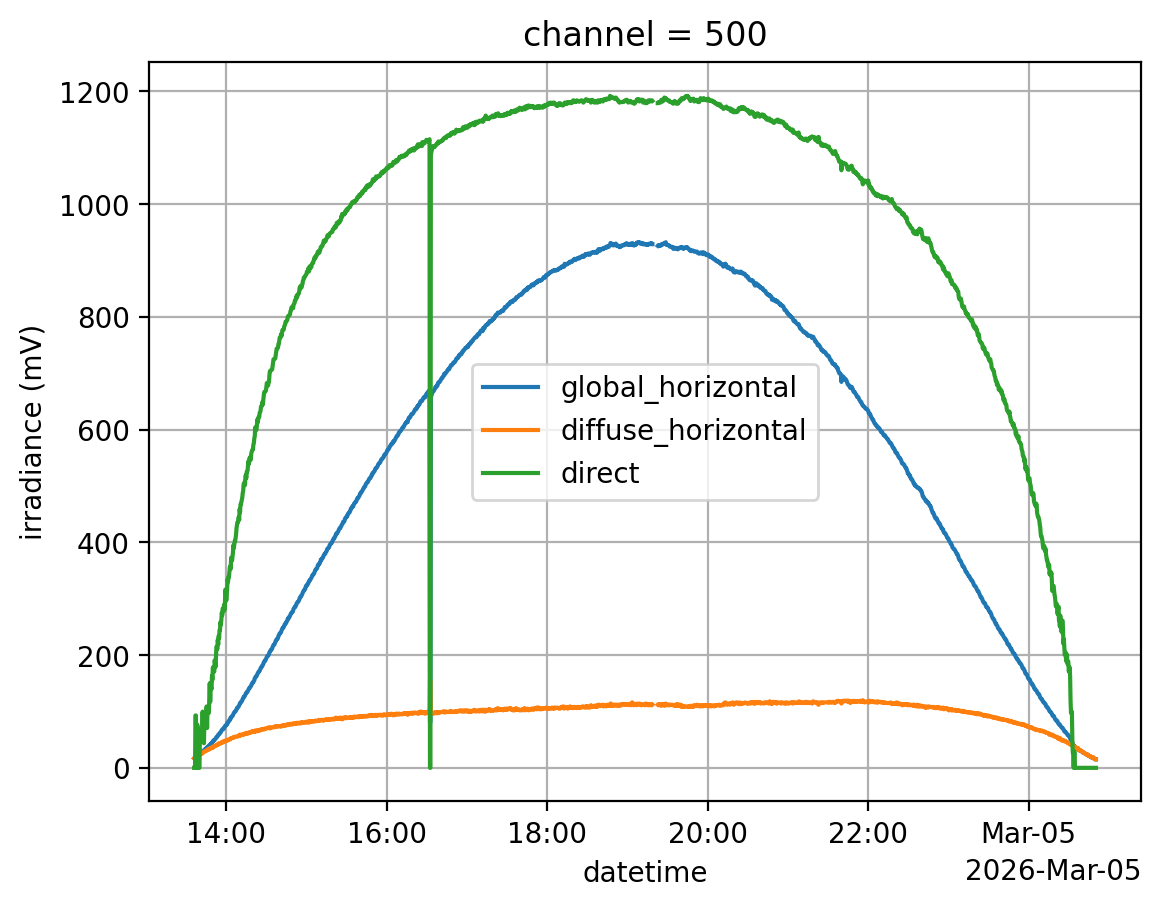

In [13]:
f,a = si_tu.plot_overview(channel=500)
a.set_ylabel('irradiance (mV)')

In [14]:
%matplotlib widget

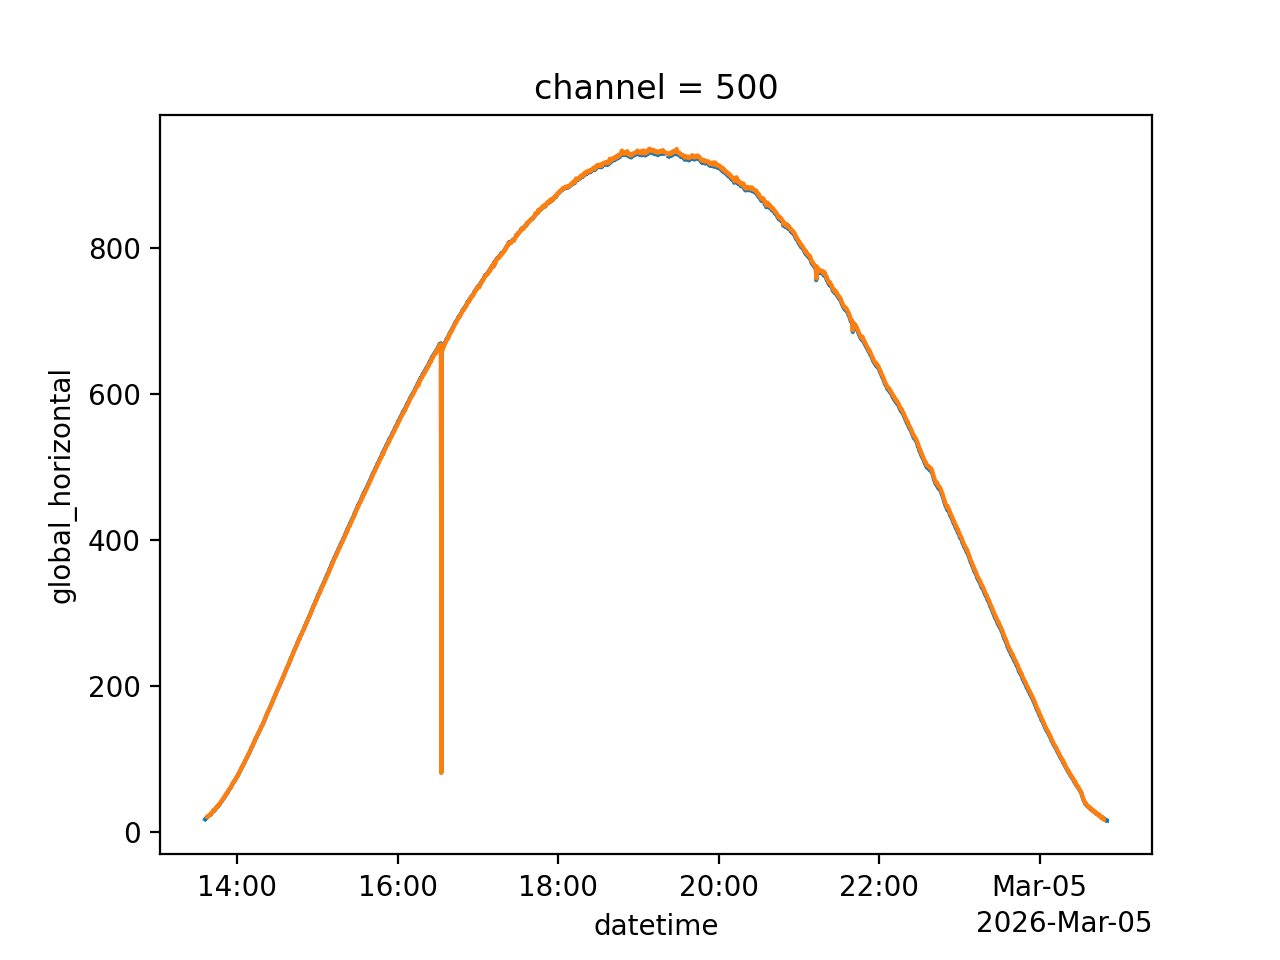

In [15]:
f,a = plt.subplots()
wl = 500
tu_raw.global_horizontal_irradiation.sel(channel = wl).plot(ax = a)
# dscc.dataset.global_horizontal_irradiation.sel(channel = wl).plot(ax = a)
dscc.dataset.global_horizontal.sel(channel = wl).plot(ax = a)

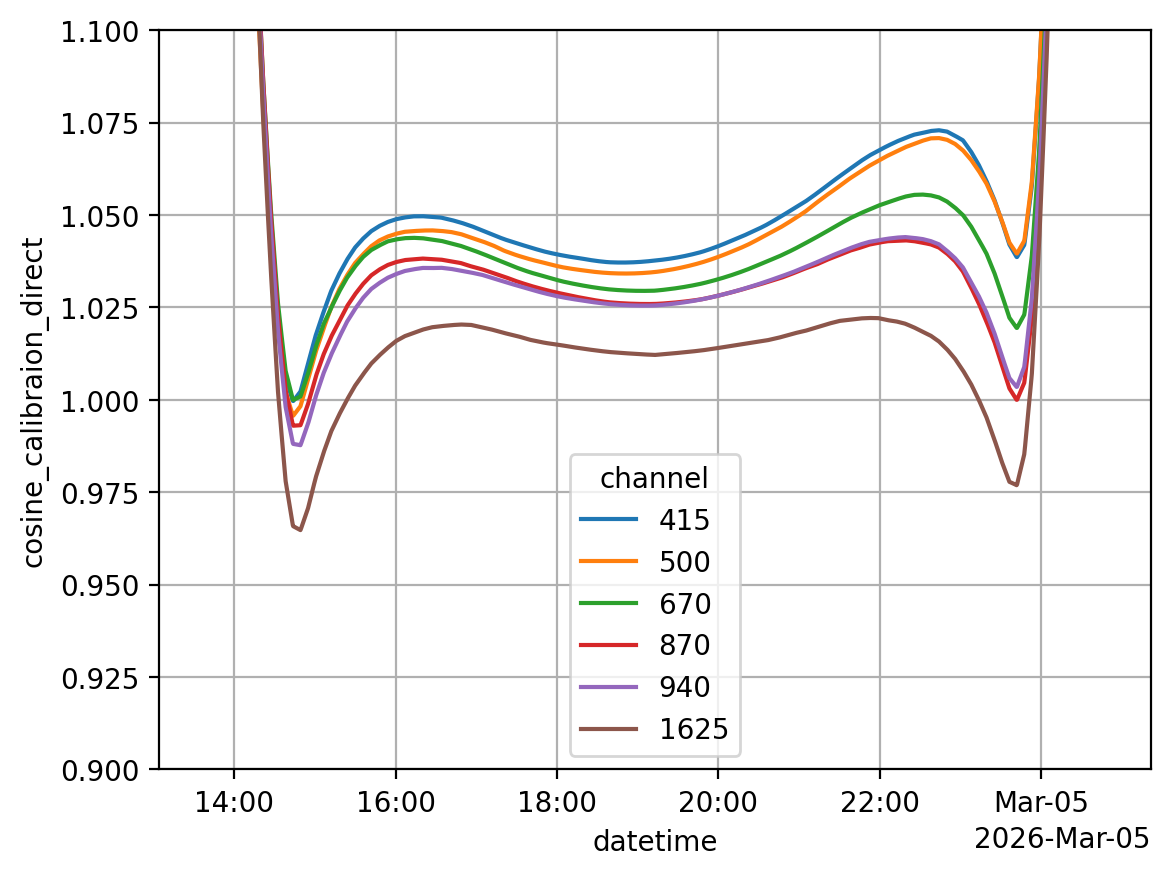

In [53]:
f,a = plt.subplots()
dscc.dataset.cosine_calibraion_direct.plot.line(x = 'datetime', ax = a)
a.set_ylim(0.9, 1.1)
a.grid(True)

(1.0, 5.0)

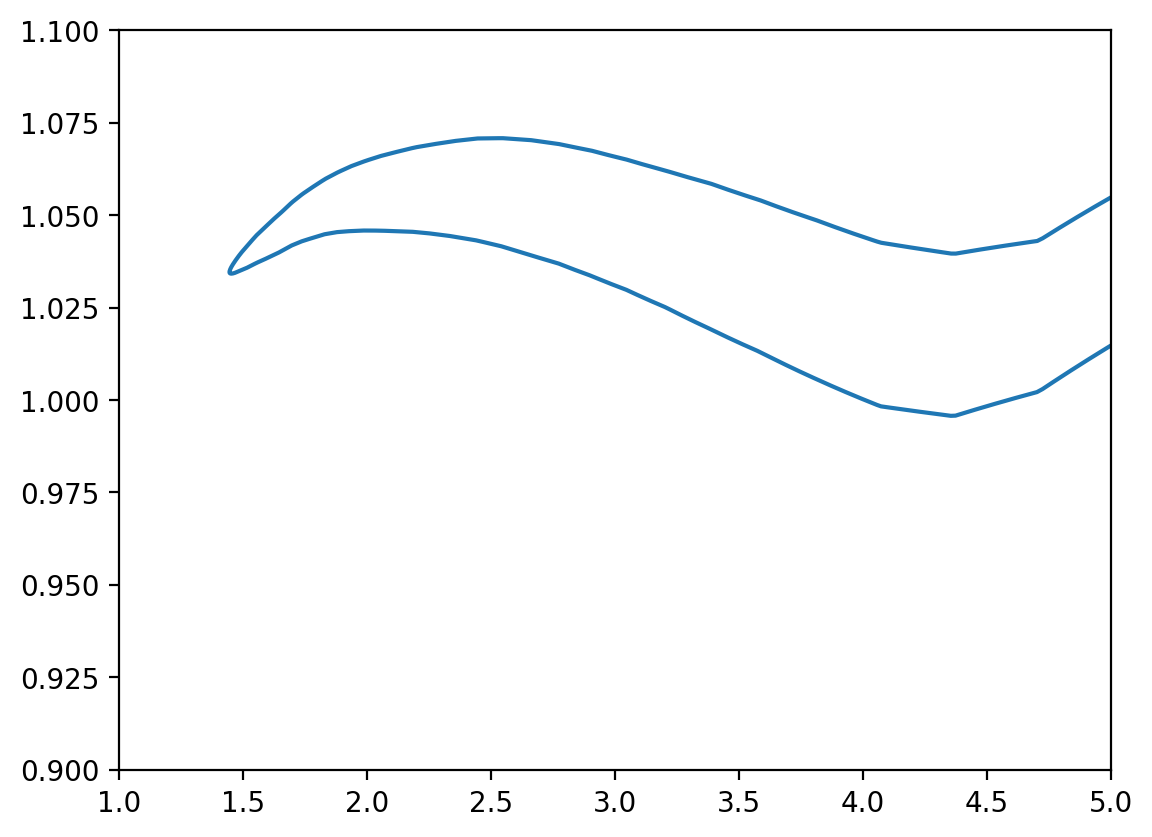

In [54]:
f,a = plt.subplots()
a.plot(dscc.dataset.airmass,dscc.dataset.cosine_calibraion_direct.sel(channel = 500))
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

(1.0, 5.0)

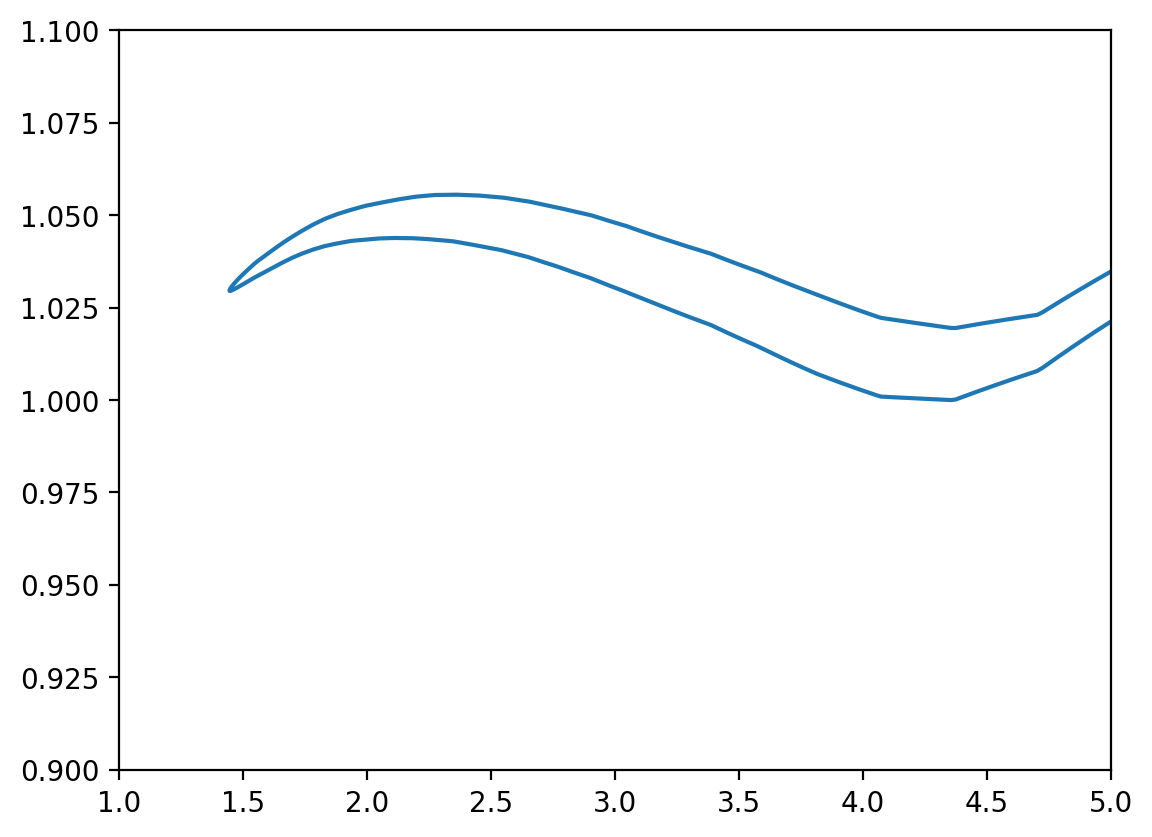

In [55]:
f,a = plt.subplots()
a.plot(dscc.dataset.airmass,dscc.dataset.cosine_calibraion_direct.sel(channel = 670))
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

(1.0, 5.0)

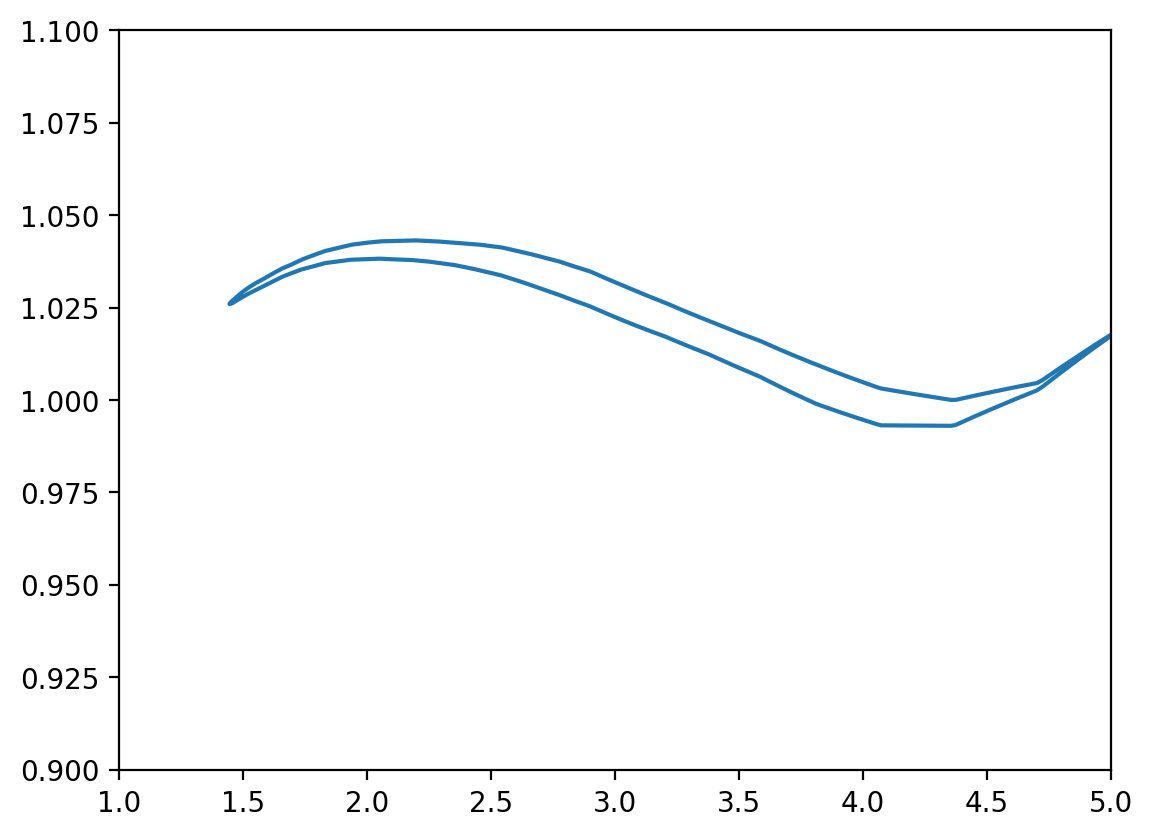

In [56]:
f,a = plt.subplots()
a.plot(dscc.dataset.airmass,dscc.dataset.cosine_calibraion_direct.sel(channel = 870))
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

(1.0, 5.0)

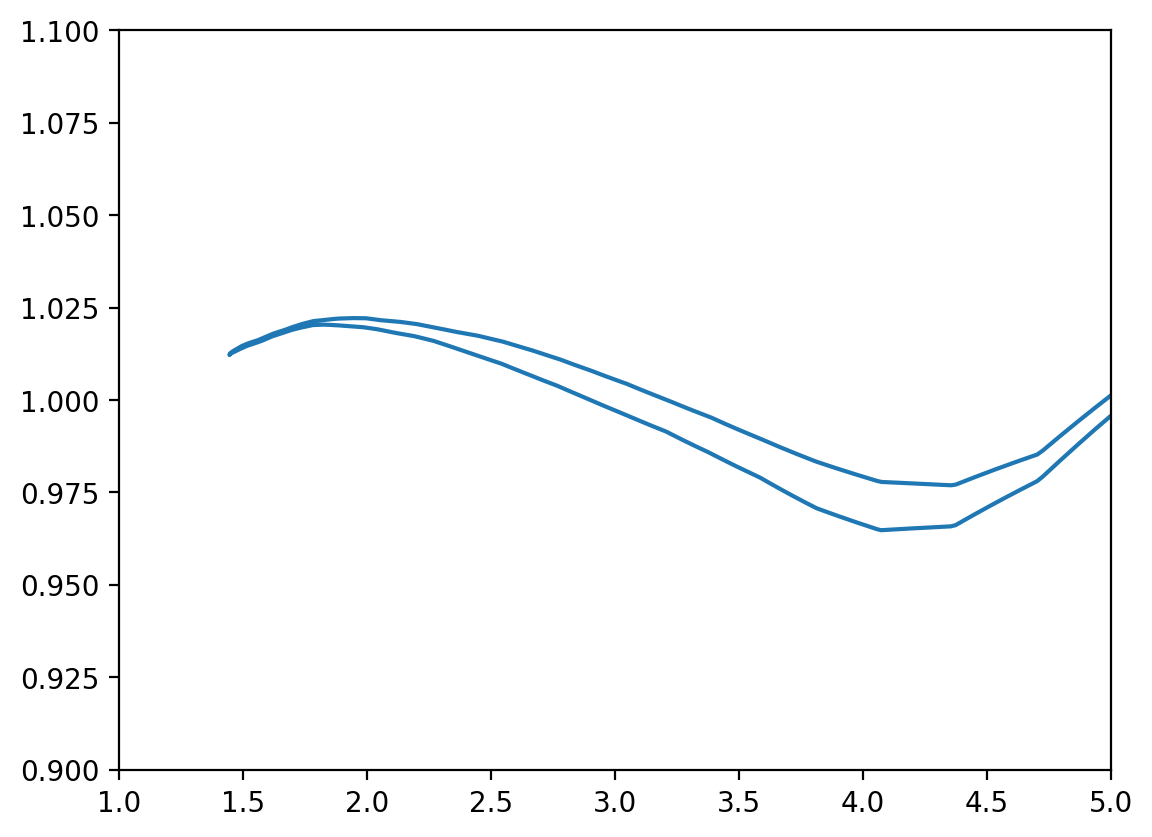

In [57]:
f,a = plt.subplots()
a.plot(dscc.dataset.airmass,dscc.dataset.cosine_calibraion_direct.sel(channel = 1625))
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

In [61]:
wl = 415
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

In [62]:
wl = 500
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

In [63]:
wl = 670
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

In [64]:
wl = 870
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

In [65]:
wl = 1625
dacc = dscc.dataset.direct_normal.sel(channel= wl)
datu = si_tu.dataset.direct_normal.sel(channel = wl)

datu = datu.reindex(datetime = dacc.datetime, method = 'closest')

f,a = plt.subplots()
a.plot(dscc.dataset.airmass, dacc/datu)
a.set_ylim(0.9,1.1)
a.set_xlim(1,5)

# Langleys

## am

In [23]:
%matplotlib inline

In [16]:
amr = [2.2,5]

In [17]:
dscc.direct_normal_irradiation._am = None
dscc.direct_normal_irradiation._pm = None
dscc.direct_normal_irradiation.settings_langley_airmass_limits = amr

In [18]:
si_tu.direct_normal_irradiation._am = None
si_tu.direct_normal_irradiation._pm = None
si_tu.direct_normal_irradiation.settings_langley_airmass_limits = amr

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

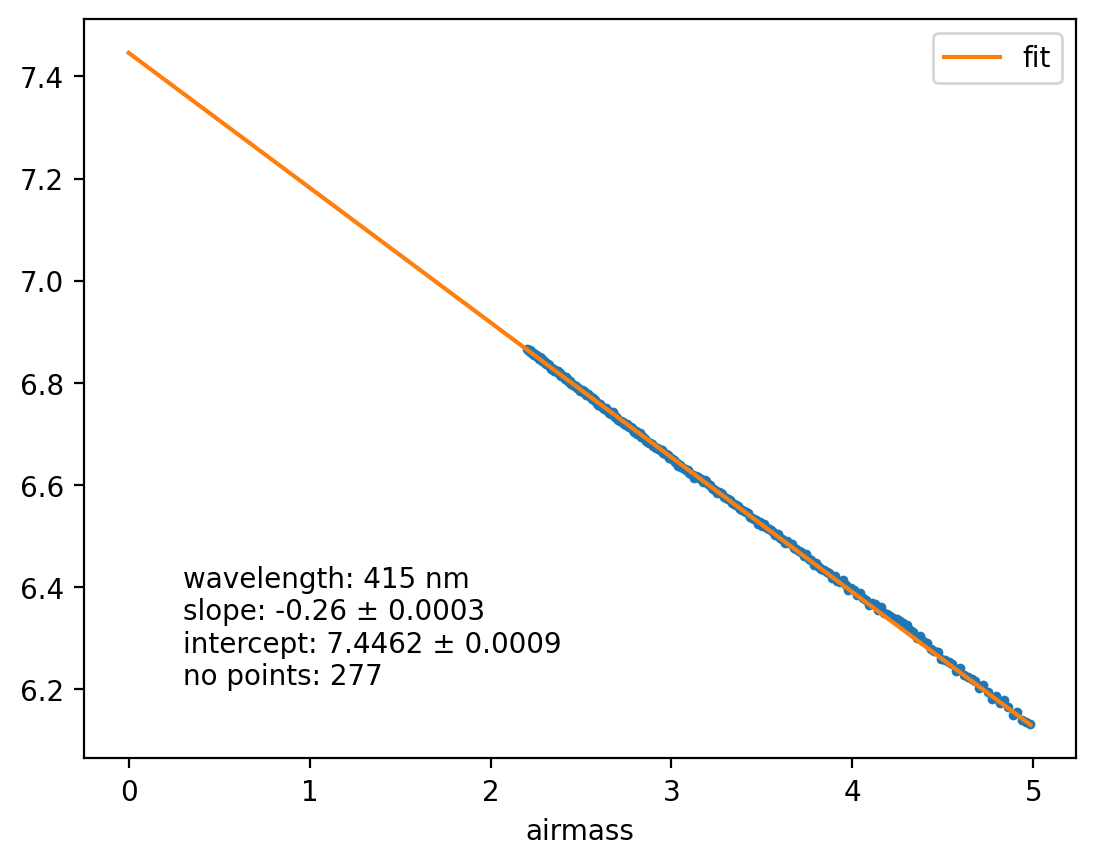

In [33]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=415, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

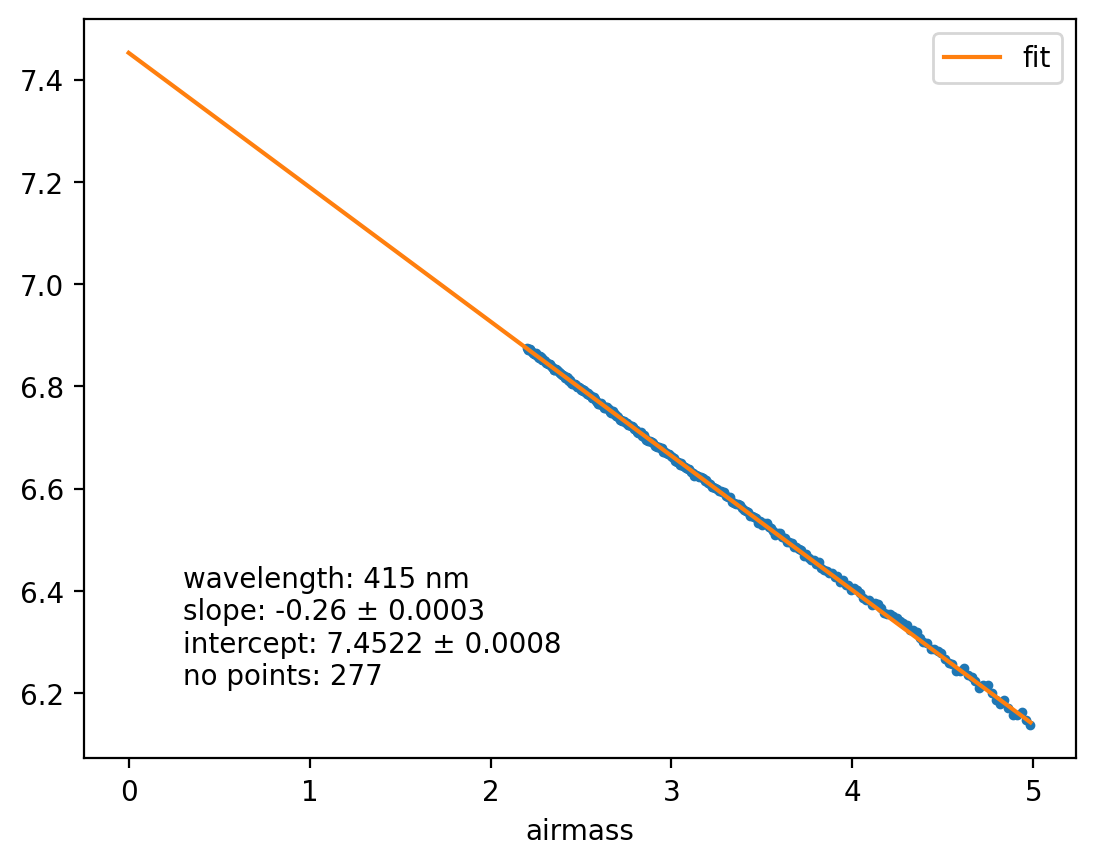

In [34]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=415, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

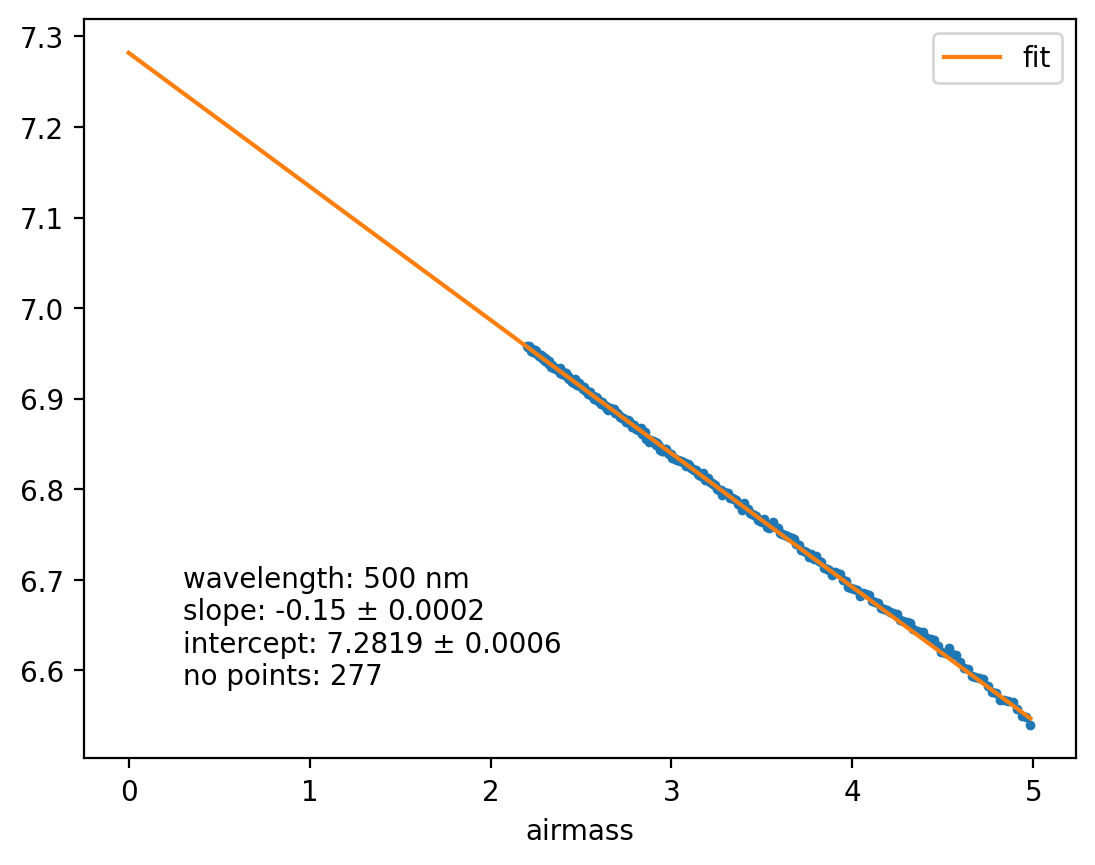

In [35]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

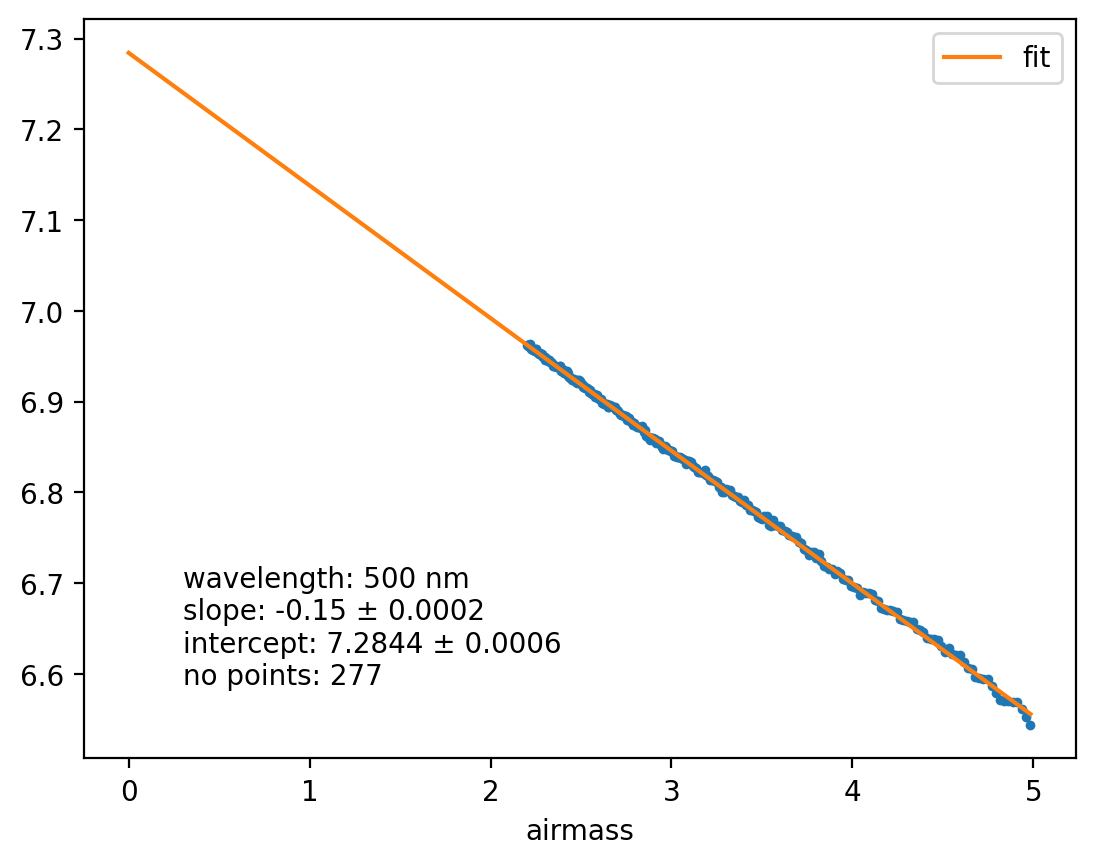

In [36]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

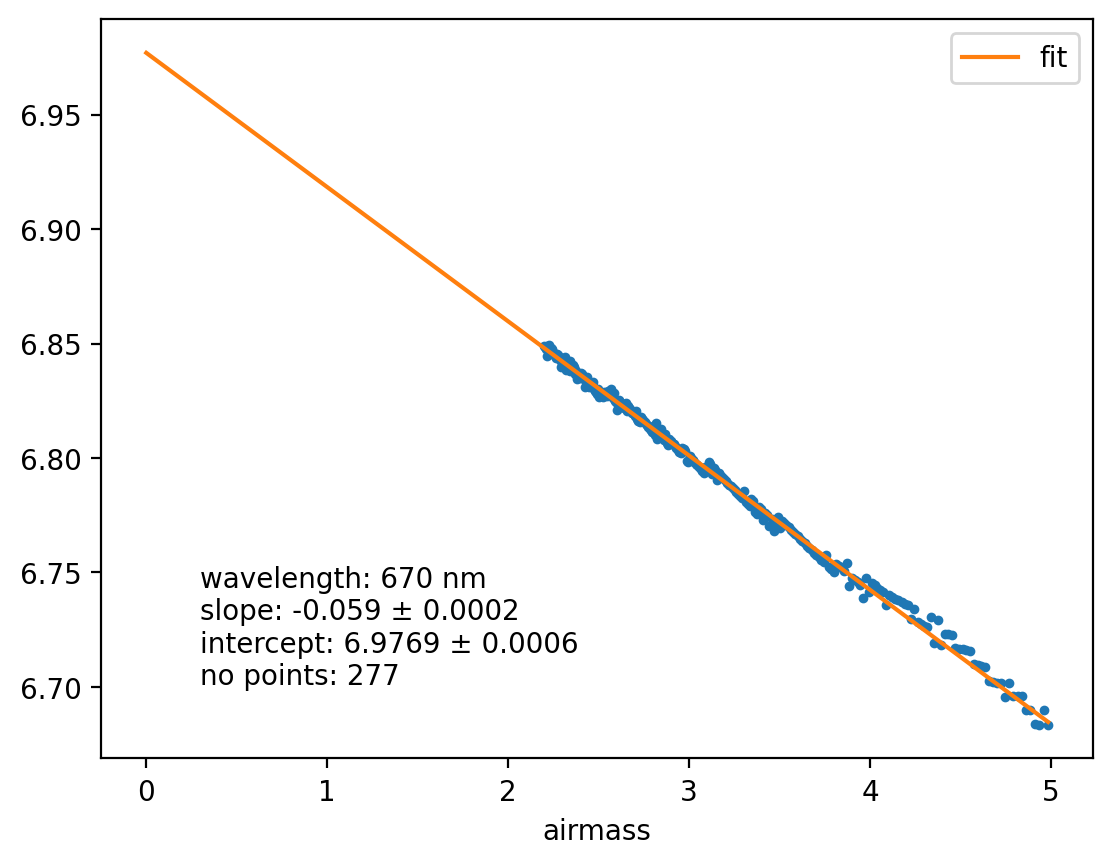

In [37]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=670, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

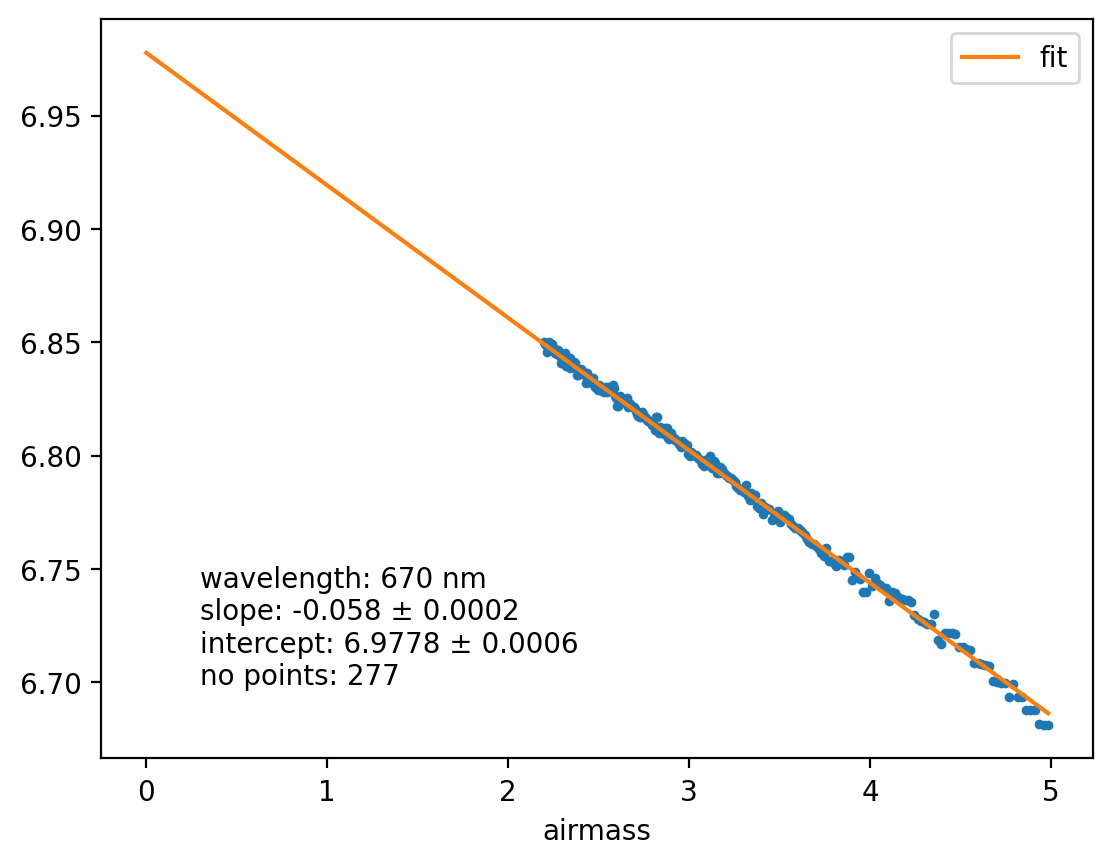

In [38]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=670, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

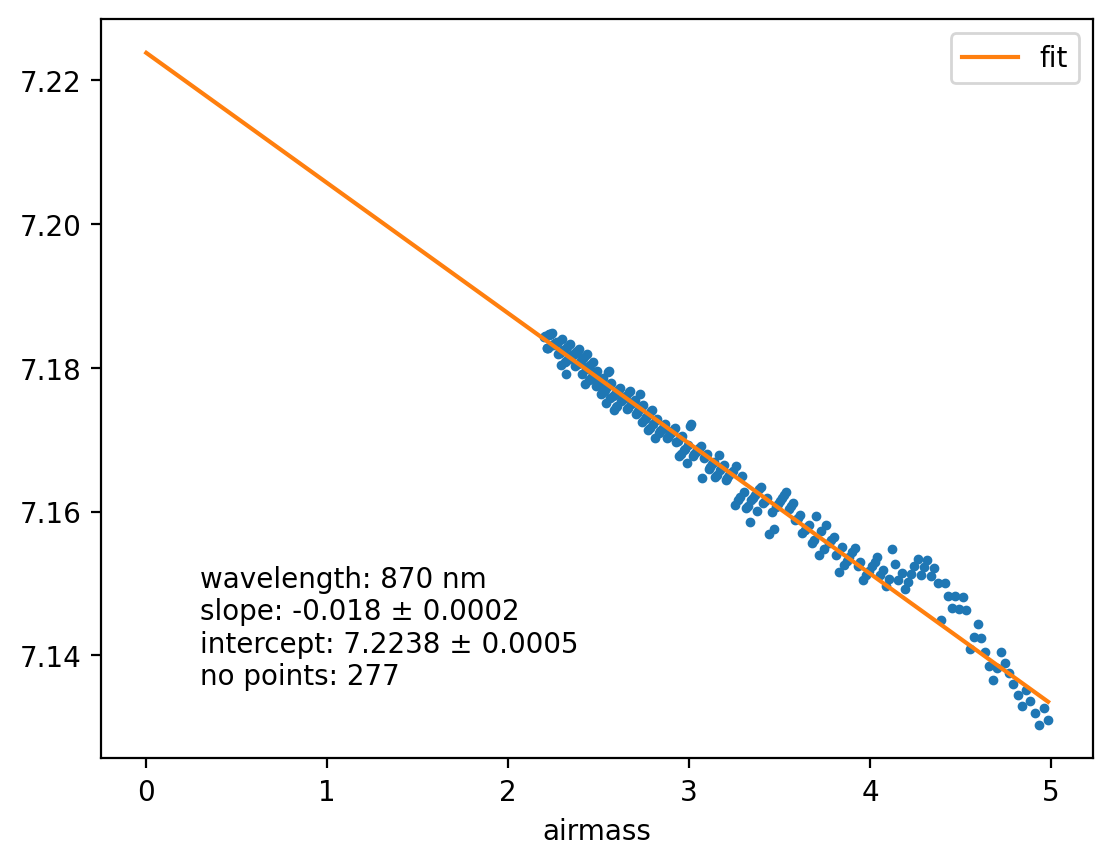

In [39]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

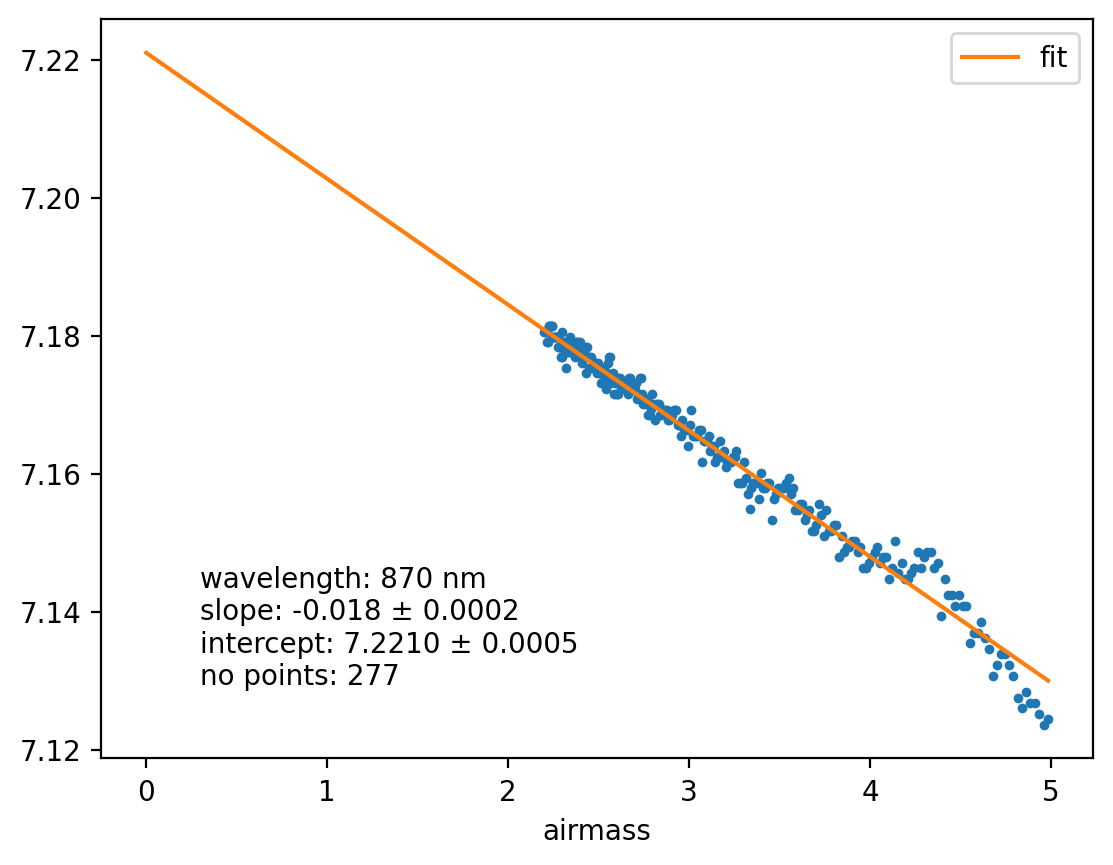

In [40]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

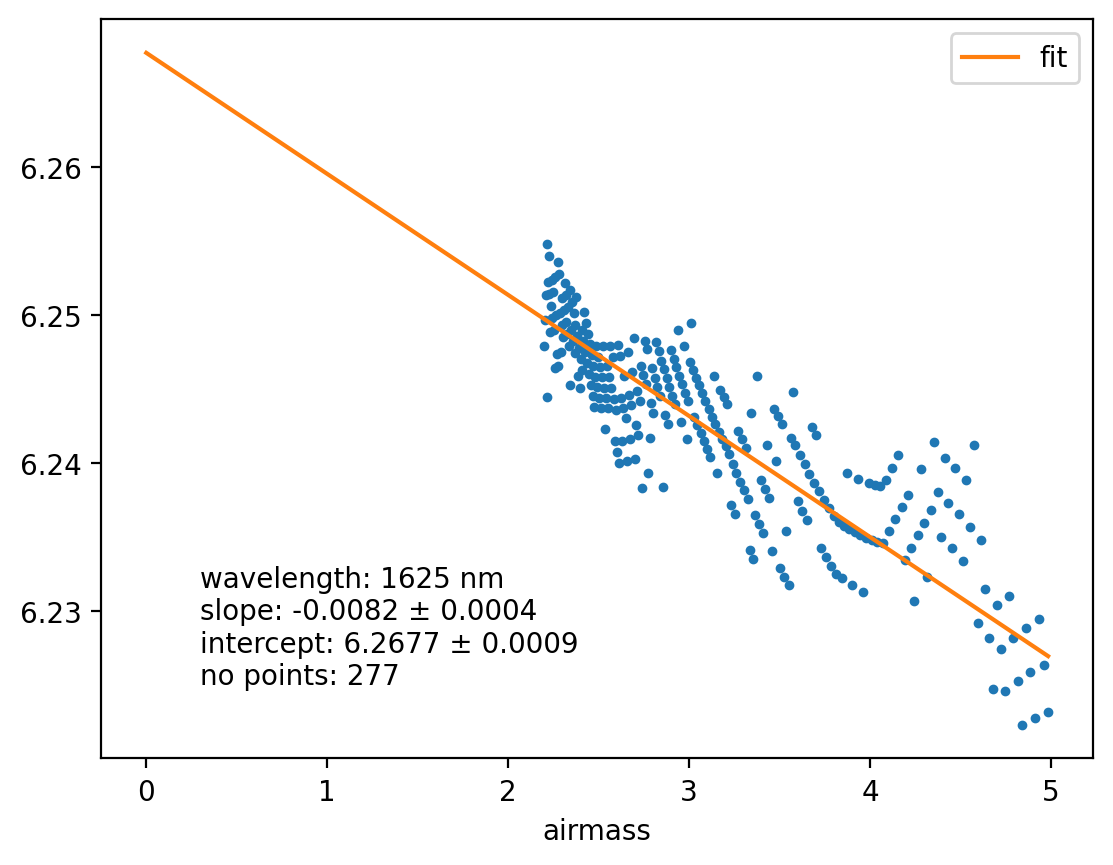

In [41]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=1625, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

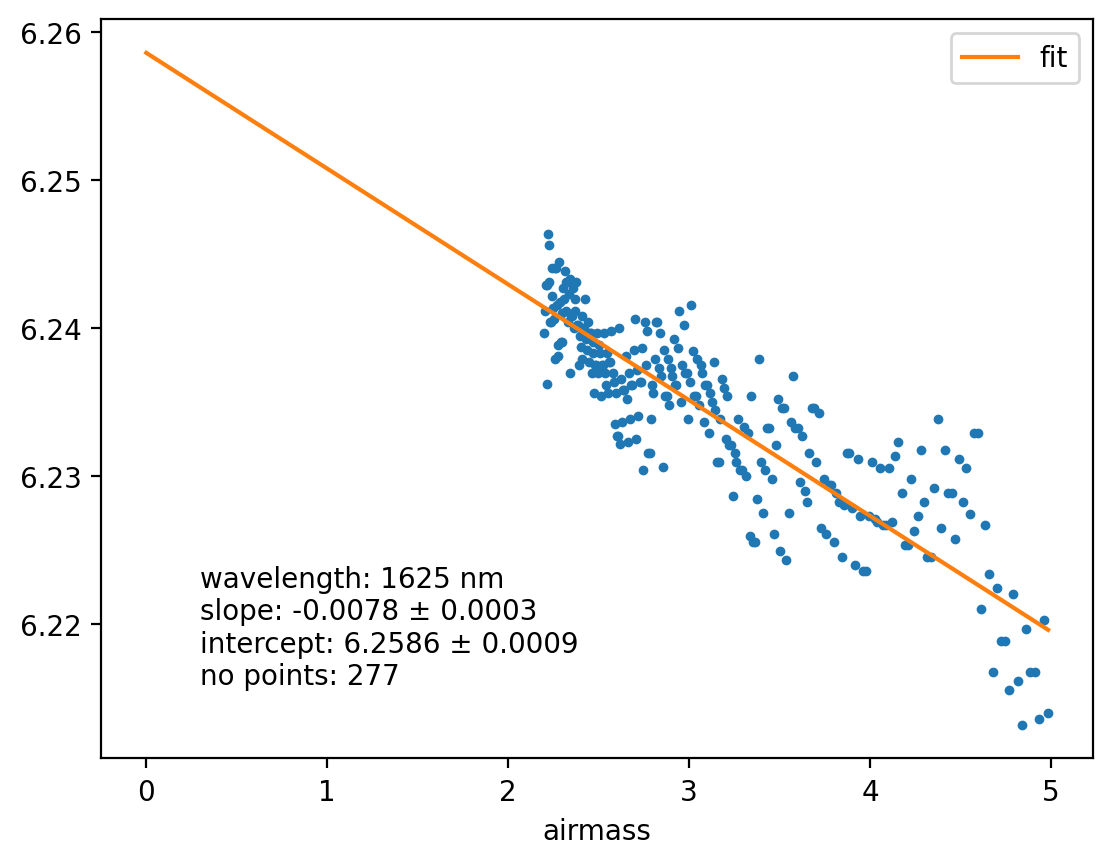

In [42]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=1625, show_pre_clean=False)

## pm

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

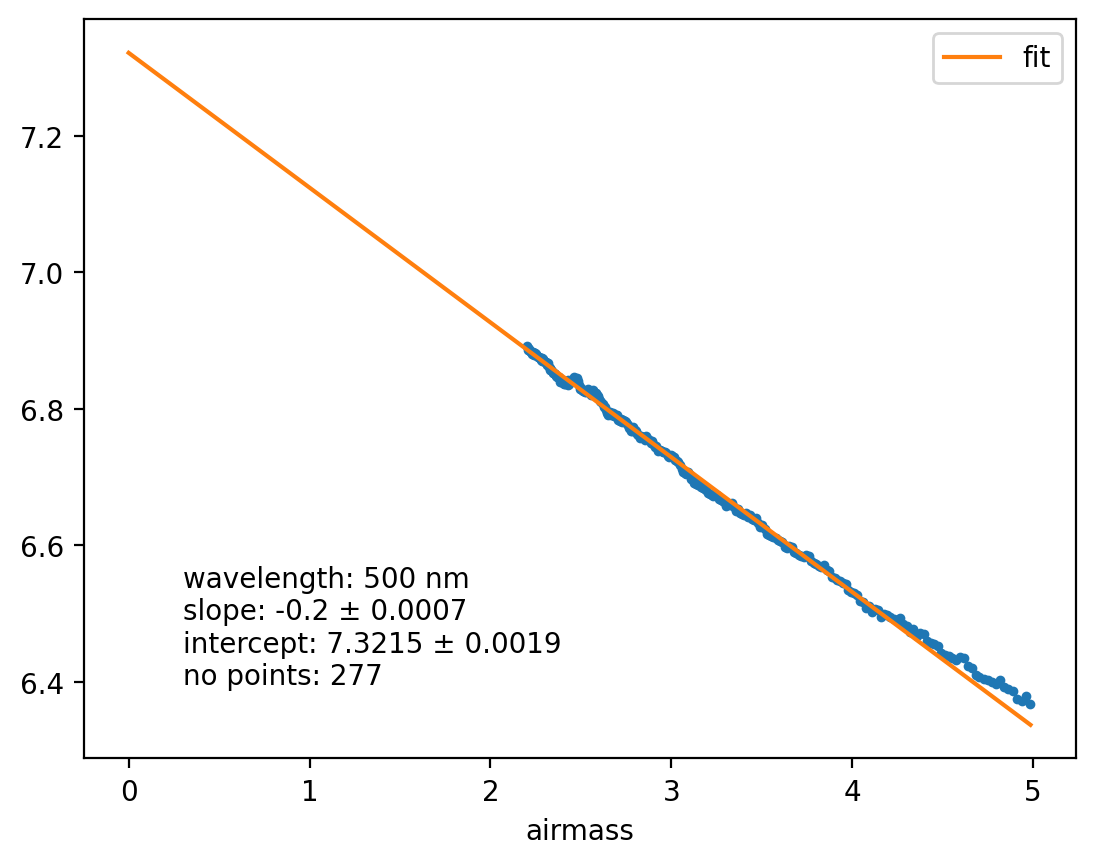

In [43]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

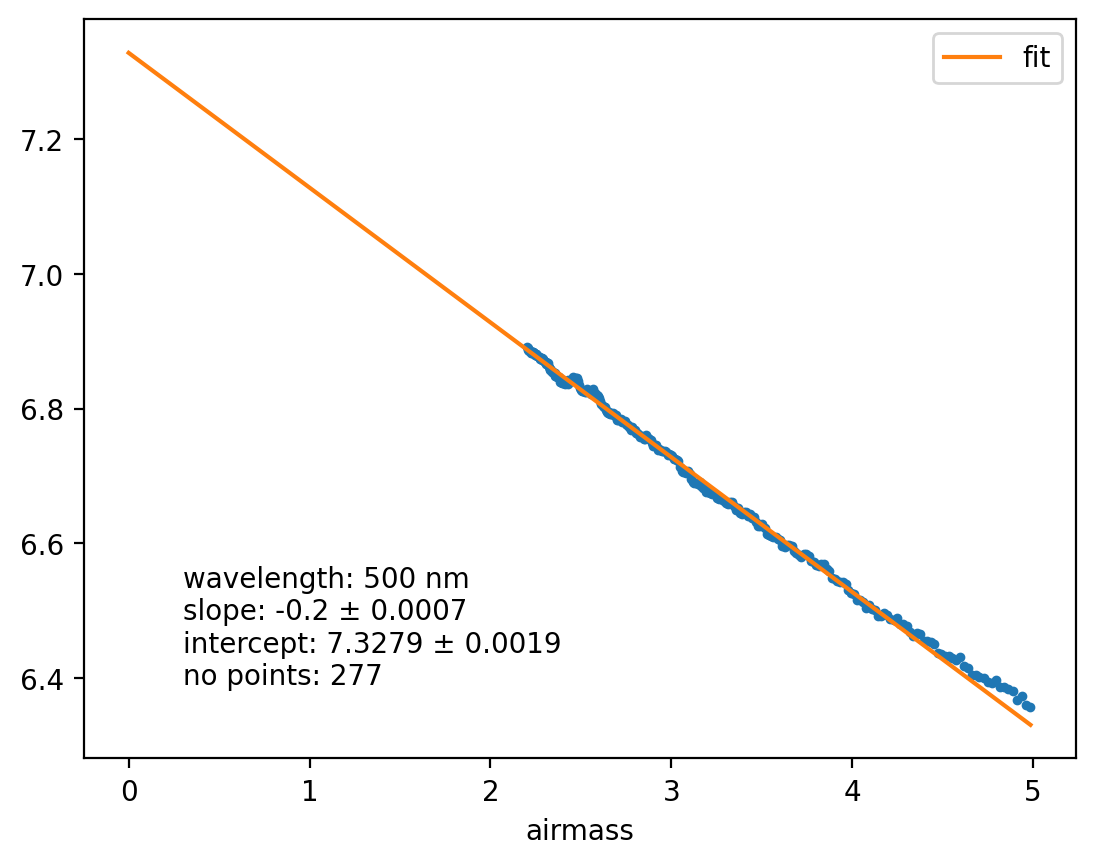

In [44]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

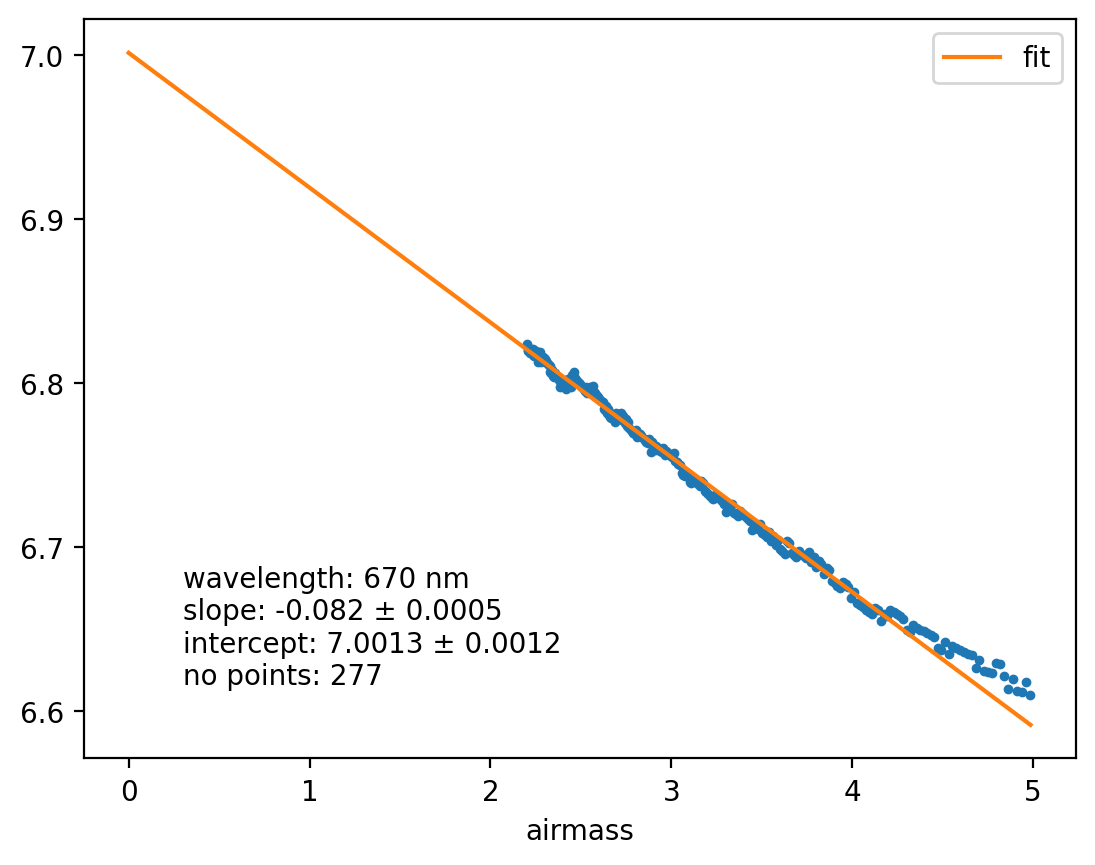

In [48]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=670, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

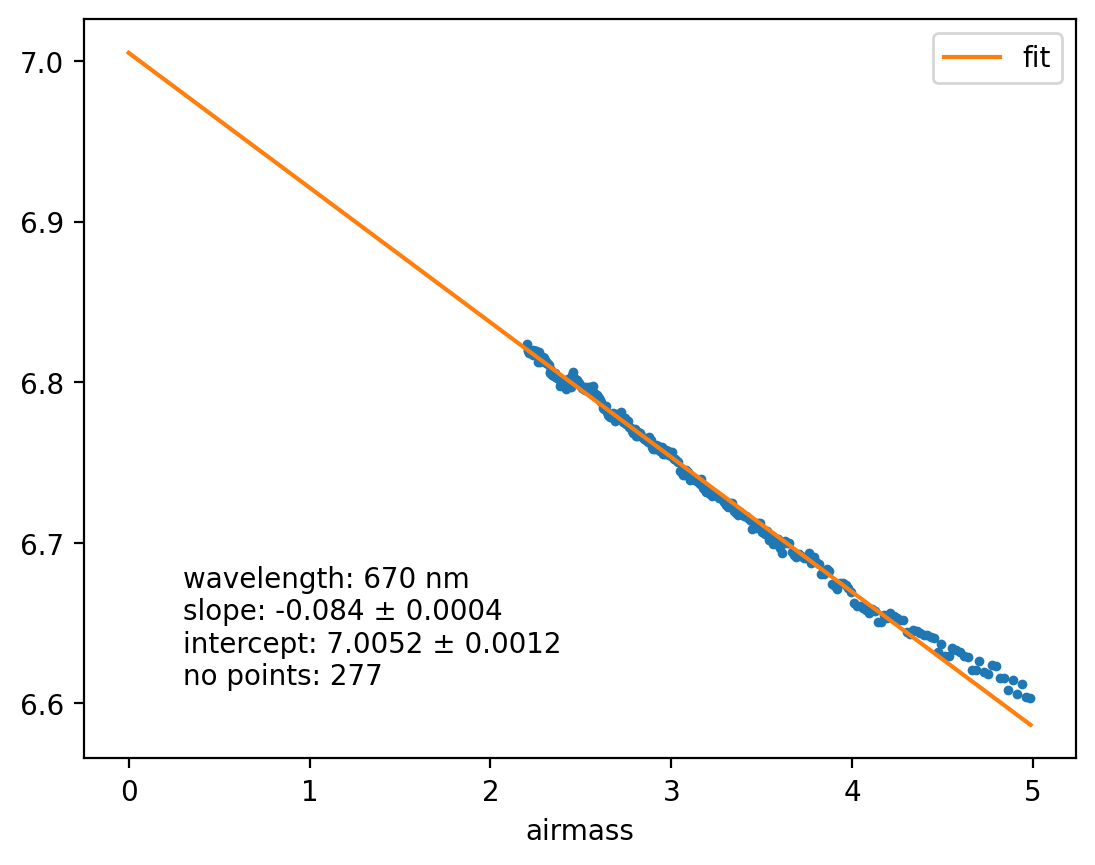

In [50]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=670, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

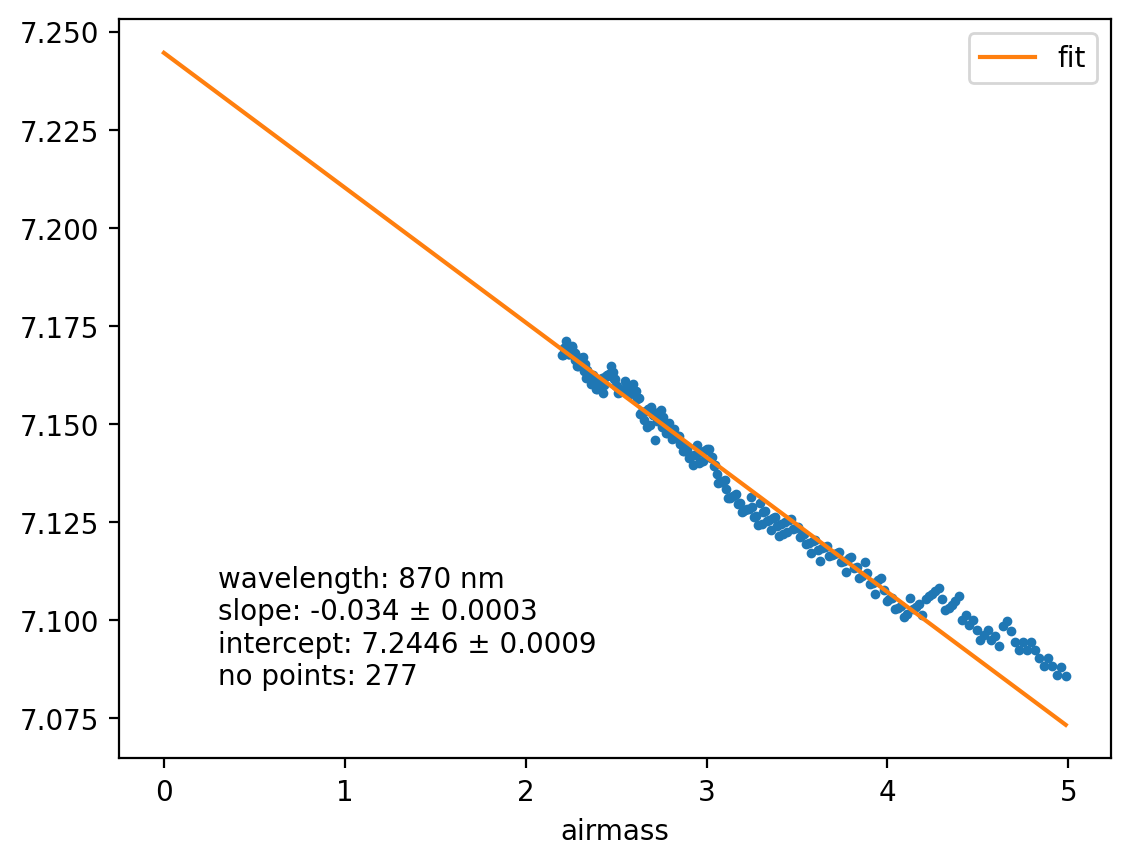

In [45]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

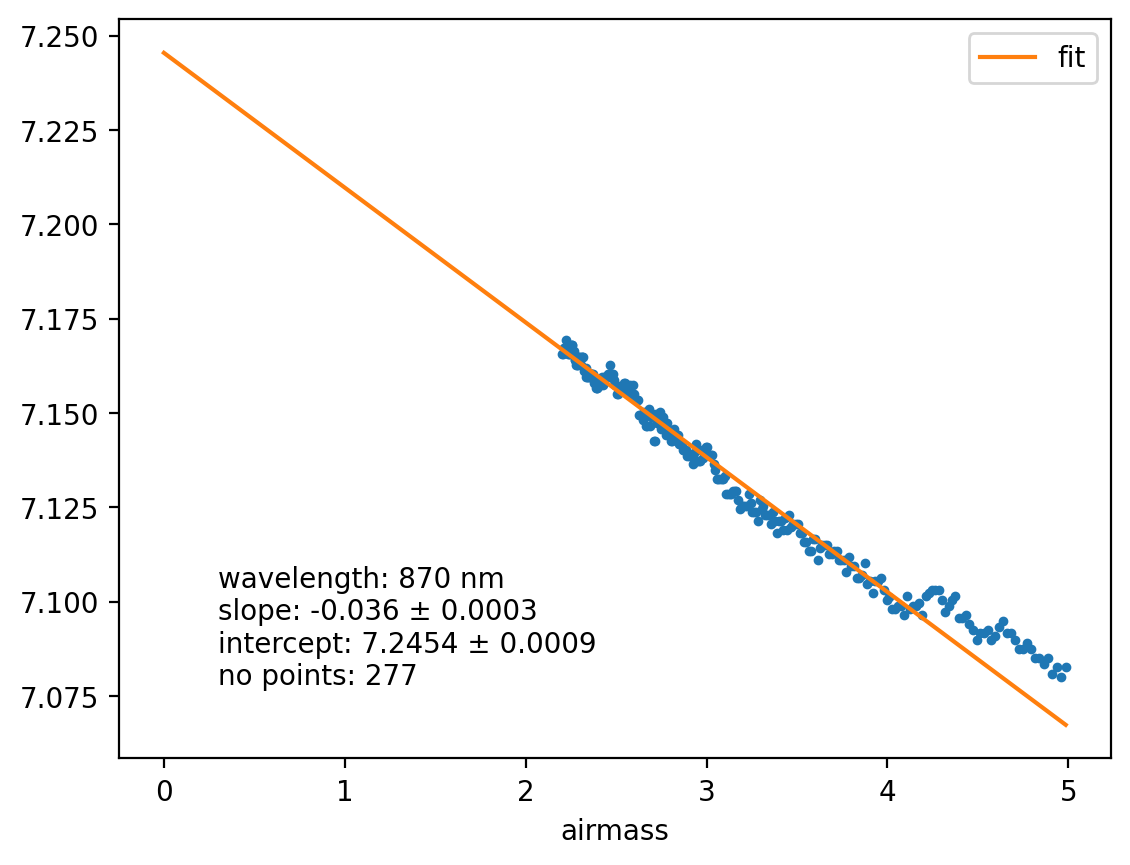

In [46]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

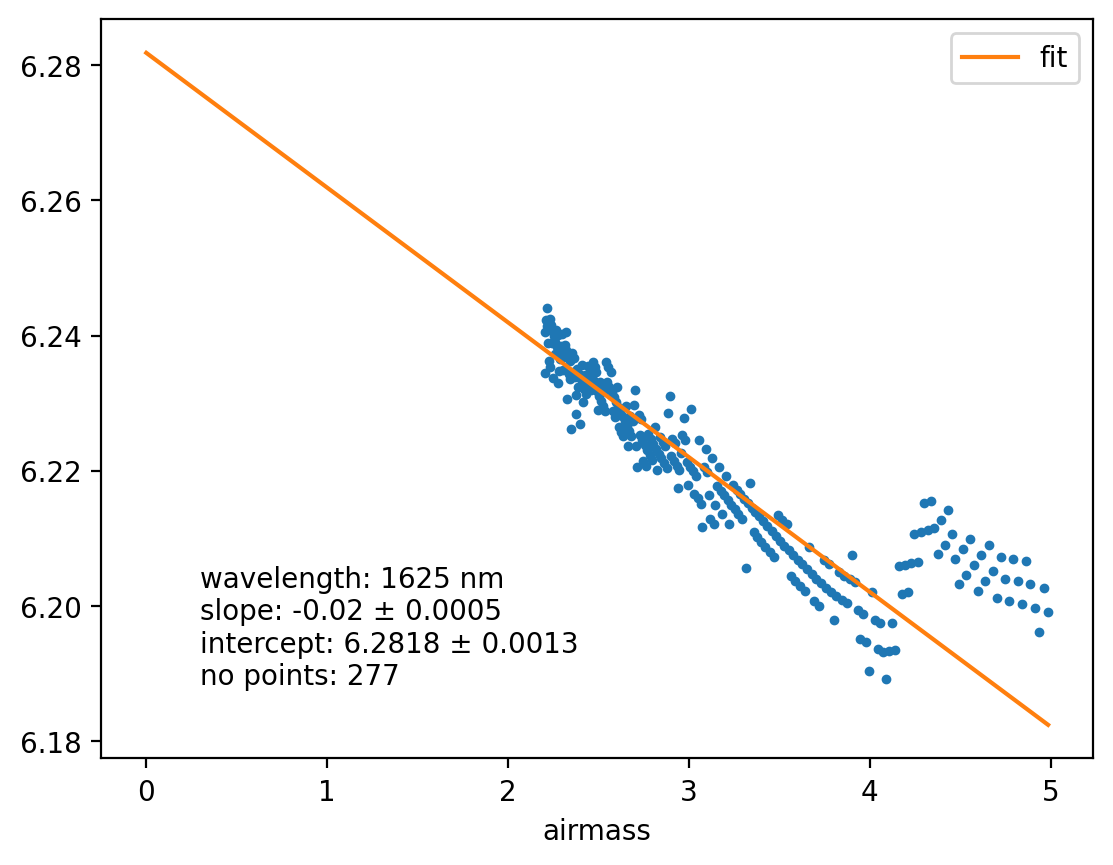

In [51]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=1625, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

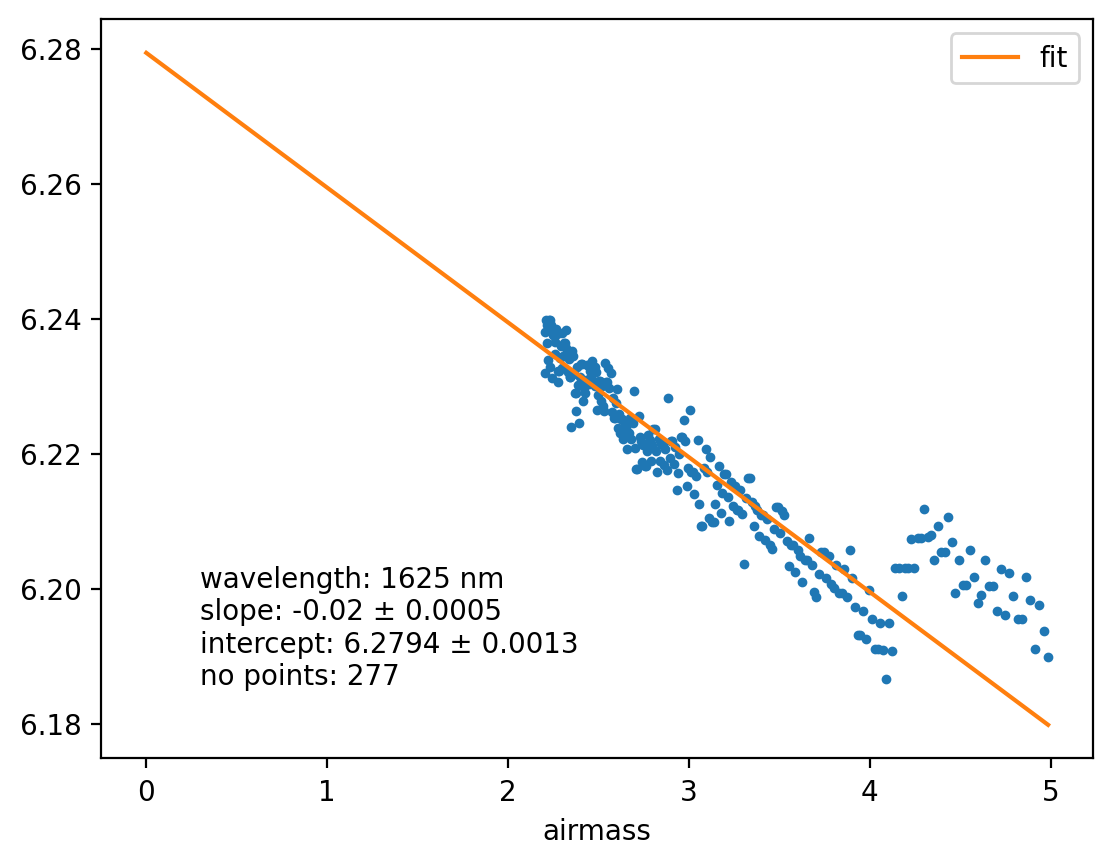

In [52]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=1625, show_pre_clean=False)

In [47]:
df = pd.DataFrame()
df['dscc_am'] = dscc.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['tu_am'] = si_tu.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['dscc_pm'] = dscc.direct_normal_irradiation.langley_pm.langley_fitres.intercept
df['tu_pm'] = si_tu.direct_normal_irradiation.langley_pm.langley_fitres.intercept

# df['tu_ratio'] = df.tu_am/df.tu_pm
# df['tu_dif'] = df.tu_am - df.tu_pm
# df['dscc_dif'] = df.dscc_am - df.dscc_pm

df['tu_dif'] = np.exp(df.tu_am) - np.exp(df.tu_pm)
df['dscc_dif'] = np.exp(df.dscc_am) - np.exp(df.dscc_pm)

df['tu_uc'] = df.tu_dif / np.exp(df.tu_am)
df['dscc_uc'] = df.dscc_dif / np.exp(df.dscc_am)

df['tuVSdscc'] = abs(((np.exp(df['dscc_am']) + np.exp(df['dscc_pm']))/2) - ((np.exp(df['tu_am']) + np.exp(df['tu_pm']))/2))
df['tuVSdscc_rel'] = df.tuVSdscc / np.exp((df['dscc_am'] + df['dscc_pm'])/2)

df

,dscc_am,tu_am,dscc_pm,tu_pm,tu_dif,dscc_dif,tu_uc,dscc_uc,tuVSdscc,tuVSdscc_rel
wavelength,,,,,,,,,,
415,7.446200,7.452191,7.495427,7.507406,-97.847764,-86.451695,-0.056768,-0.050458,15.991967,0.009107
500,7.281887,7.284450,7.321546,7.327898,-64.720638,-58.811399,-0.044406,-0.040456,6.684231,0.004508
670,6.976946,6.977755,7.001290,7.005154,-29.790972,-26.407788,-0.027777,-0.024642,2.559288,0.002359
870,7.223820,7.220983,7.244607,7.245409,-33.822311,-28.812157,-0.024727,-0.021004,1.381109,0.000996
940,7.259266,7.254301,7.308896,7.308840,-79.270541,-72.314948,-0.056054,-0.050883,3.560867,0.002444
1625,6.267706,6.258616,6.281823,6.279369,-10.956363,-7.495883,-0.020969,-0.014216,3.040850,0.005727
